In [51]:
import pandas as pd
import os
import numpy as np
def processMain(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))

    # Use the next line for finished ins
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A3_0_15_N"+str(N)+"_")]
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A2_1_15_N"+str(N)+"_")]
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        num_rows = sum(1 for line in open(filename))
        df = pd.read_csv(''+filename, sep=';', names=['iiter','','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K','SAcalls','SAexec'], header=None, skiprows=num_rows-1, nrows=1)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
N = 50
df_A2_1 = processMain(N)
df_A2_1
# df_A2_1.to_csv("N"+str(N)+"_15_main_A2_1_df.csv")

#<5min

# ins = [1, 2, 5, 6, 7, 8, 9, 10, 11, 12]#N30
# ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13] #N40: 1 3 5 6 7 9 10 11 12 13 xxx
# ins = [2, 6, 7, 10, 13, 14, 15, 16, 17, 21]#N50: 2 6 7 10 13 14 15 16 17 21 xxx

#5-60min
# ins = [4, 20, 83, 89, 107, 166, 172, 174, 200, 241]#N30: 4 20 83 89 107 166 172 174 200 241 xxx
# ins = [4, 8, 16, 20, 27, 28, 33, 36, 37, 48]#N40: 4 8 16 20 27 28 33 36 37 48 xxx
# ins = [18, 26, 30, 46, 73, 93, 98, 110, 113, 122]#N50: 18 26 30 46 73 93 98 110 113 122 xxx

#>60min
# ins = [3, 35, 36, 37, 52, 63, 64, 150, 282, 319]#N30: 3 35 36 37 52 63 64 150 282 319 xxx
# ins = [2, 14, 18, 22, 24, 38, 39, 40, 56, 76] #N40: 2 14 18 22 24 38 39 40 56 76 xxx
ins = [1, 3, 4, 5, 8, 9, 11, 12, 19, 20] #N50: 1 3 4 5 8 9 11 12 19 20 xxx


df_filtered = df_A2_1[df_A2_1['Ins'].isin(ins)]
df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100
print("Average Sol Time ", df_filtered['total_time'].mean())
print("Average |K| ", df_filtered['K'].mean())
print("Average Opt Gap ", df_filtered["OptGap"].mean())
print("Number of solved ins ", len(df_filtered))
print("Number of SA calls/exec ", df_filtered['SAexec'].mean(), "(",df_filtered['SAcalls'].mean(),")")
# df_A2_1[df_A2_1['Ins'].isin(ins)]
df_filtered


Average Sol Time  1009.8926900227865
Average |K|  4175.0
Average Opt Gap  0.8553305007789893
Number of solved ins  3
Number of SA calls/exec  412.5 ( 1156.0 )


/var/folders/cy/c941bw5943jb9bfdpqrp1g180000gn/T/ipykernel_9029/544828564.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100


,iiter,,total_time,b,ObjVal,LB,x_sol,Kbar,K,SAcalls,SAexec,Ins,OptGap
4,-1,NaN,2485.720409,10,183.975894,182.308339,[ 1 5 10 50 51 105 116 124 134 288],0,10211,NaN,NaN,3,0.906399
6,-1,NaN,479.682829,10,315.965056,313.394523,[ 5 118 158 211 256 258 266 286 341 360],0,1999,1998.0,704.0,19,0.813550
21,-1,NaN,64.274832,10,176.987343,175.489954,[ 0 111 112 113 151 175 183 210 248 362],0,315,314.0,121.0,12,0.846043


In [95]:
import pandas as pd
import os
import numpy as np
def processIter(N,ins):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    fileNames = []
    # Iterate through files in the directory
    for i in ins:
        fileNames.append("./Iter/main_A3_0_15_N"+str(N)+"_"+str(i)+".txt")
        # fileNames.append("./Iter/main_A3_0_15_N"+str(N)+"_"+str(i)+".txt")
    print(fileNames)
    
    # Use the next line for finished ins
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_A3_0_15_N"+str(N)+"_")]
    # print(prefixed)
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A2_1_15_N"+str(N)+"_")]
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in fileNames:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        num_rows = sum(1 for line in open(""+filename))
        # print(num_rows)
        df = pd.read_csv(''+filename, sep=';', names=['iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K','SAcalls','SAexec'], header=None, skiprows=num_rows-2, nrows=2)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)

    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
N = 30

#<5min
ins = [1, 2, 5, 6, 7, 8, 9, 10, 11, 12]#N30
# ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13] #N40: 1 3 5 6 7 9 10 11 12 13 xxx
# ins = [2, 6, 7, 10, 13, 14, 15, 16, 17, 21]#N50: 2 6 7 10 13 14 15 16 17 21 xxx

#5-60min
# ins = [4, 20, 83, 89, 107, 166, 172, 174, 200, 241]#N30: 4 20 83 89 107 166 172 174 200 241 xxx
# ins = [4, 8, 16, 20, 27, 28, 33, 36, 37, 48]#N40: 4 8 16 20 27 28 33 36 37 48 xxx
# ins = [18, 26, 30, 46, 73, 93, 98, 110, 113, 122]#N50: 18 26 30 46 73 93 98 110 113 122 xxx

#>60min
# ins = [3, 35, 36, 37, 52, 63, 64, 150, 282, 319]#N30: 3 35 36 37 52 63 64 150 282 319 xxx
# ins = [2, 14, 18, 22, 24, 38, 39, 40, 56, 76] #N40: 2 14 18 22 24 38 39 40 56 76 xxx
# ins = [1, 3, 4, 5, 8, 9, 11, 12, 19, 20] #N50: 1 3 4 5 8 9 11 12 19 20 xxx


df_main = processIter(N,ins)
# df_main
df_filtered = df_main.groupby('Ins').apply(
    lambda group: group[group['iiter'] == group['iiter'].max()])
# df_filtered
df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100

# print(df_filtered["OptGap"].mean())
# print(df_main_filtered['K'].mean())
print("Average iter ", df_filtered['iiter'].mean()+1)
print("Average |K| ", df_filtered['K'].mean())
print("Average Opt Gap ", df_filtered["OptGap"].mean())
print("num ins solved ", len(df_filtered))
df_filtered



['./Iter/main_A3_0_15_N30_1.txt', './Iter/main_A3_0_15_N30_2.txt', './Iter/main_A3_0_15_N30_5.txt', './Iter/main_A3_0_15_N30_6.txt', './Iter/main_A3_0_15_N30_7.txt', './Iter/main_A3_0_15_N30_8.txt', './Iter/main_A3_0_15_N30_9.txt', './Iter/main_A3_0_15_N30_10.txt', './Iter/main_A3_0_15_N30_11.txt', './Iter/main_A3_0_15_N30_12.txt']
Average iter  8.421052631578949
Average |K|  19.0
Average Opt Gap  29.19442481445526
num ins solved  19


iiter  total_time   b      ObjVal          LB  \
Ins                                                     
1   0       3    1.254015  10  313.000000    0.000000   
    1       3    1.291056  10  313.000000  313.000000   
2   2      15   17.090359  10  192.953550  189.350488   
    3      15   19.191801  10  192.953550  191.525713   
5   5       9    4.288696  10  282.141607   19.689286   
6   6       5    2.101166  10  164.221154  112.067308   
    7       5    2.154396  10  164.221154  164.221154   
7   8       2    0.792942  10  163.000000    0.000000   
    9       2    0.814408  10  163.000000  163.000000   
8   10      5    2.153091  10  224.607933  197.877885   
    11      5    2.218851  10  224.607933  224.555769   
9   12      3    1.294105  10  131.313596    0.000000   
    13      3    1.332575  10  131.313596  131.313596   
10  14      6    2.713941  10  209.000000  180.968750   
    15      6    2.813762  10  209.000000  209.000000   
11  16     18   13.089011  10  260.235945  257.146756   
    17     18   14.044660  10  260.235945  258.196122   
12  18      9    3.876516  10  417.000000    0.000000   
    19      9    3.898786  10  417.000000  417.000000   

                                            x_sol  Kbar    K  SAcalls  SAexec  \
Ins                                                                             
1   0   [  0   1  14  20  28  38  39  41  91 116]     2    2        1       1   
    1   [  0   1  14  20  28  38  39  41  91 116]     0    2        1       1   
2   2   [  1   2  14  19  80  86  90  91  95 128]    28  102      101      48   
    3   [  1   2  14  19  80  86  90  91  95 128]     0  109      108      51   
5   5   [  0   2  30  31  46  51  53  54  82 109]    10   12       11       6   
6   6   [  0   1   2   3  89  93  94  95 111 128]     2    3        2       2   
    7   [  0   1   2   3  89  93  94  95 111 128]     0    3        2       2   
7   8   [  0   1   2   3  13  23  94  99 120 121]     1    1        0       0   
    9   [  0   1   2   3  13  23  94  99 120 121]     0    1        0       0   
8   10  [  0   1   8   9  31  55  57  59  87 102]     2    4        3       1   
    11  [  0   1   8   9  31  55  57  59  87 102]     0    4        3       1   
9   12  [  0   1   2   3   4   7  88  90 108 109]     2    2        1       1   
    13  [  0   1   2   3   4   7  88  90 108 109]     0    2        1       1   
10  14            [ 0  1  2  3  6 15 25 28 29 75]     4    7        6       2   
    15            [ 0  1  2  3  6 15 25 28 29 75]     0    7        6       2   
11  16            [ 0  3 21 23 45 53 65 66 67 77]    12   47       46      36   
    17            [ 0  3 21 23 45 53 65 66 67 77]     0   51       50      39   
12  18  [  0   1   2  12  46  52  79  80  87 129]     1    1        0       0   
    19  [  0   1   2  12  46  52  79  80  87 129]     0    1        0       0   

        Ins      OptGap  
Ins                      
1   0     1  100.000000  
    1     1    0.000000  
2   2     2    1.867321  
    3     2    0.739990  
5   5     5   93.021488  
6   6     6   31.758300  
    7     6    0.000000  
7   8     7  100.000000  
    9     7    0.000000  
8   10    8   11.900759  
    11    8    0.023224  
9   12    9  100.000000  
    13    9    0.000000  
10  14   10   13.412081  
    15   10    0.000000  
11  16   11    1.187073  
    17   11    0.783836  
12  18   12  100.000000  
    19   12    0.000000

In [ ]:
#x Verify
#!/usr/bin/env python
# coding: utf-8

# In[1]:

import importlib
import pandas as pd
import networkx as nx;
import pandas as pd;
import gurobipy as gp;
from gurobipy import GRB;
import csv;
import sys;
import numpy as np
import time
import os 

importlib.import_module("functionProcessInputFile")
from functionProcessInputFile import processInputFile

directory = "./"

N = 30 #sys.argv[1]
testSet = "N"+sys.argv[1]
ins = 4#int(sys.argv[2])


#NEED TO PROCESS X-SOL HERE.

Len, origin, destination, edge,d,cL_orig, cU_orig = processInputFile(testSet, ins)

# In[2]:


# networkCSV = 'TestInstances/CSV_TestInstances/N100/' + 'N100_22.csv';
# N = 1000; #sample size
# budget = 5;
# numpy.random.seed(2024);

# networkCSV = './NewCSVFeb24/N10_1.csv'
num_cases = 100000 #3#int(sys.argv[3]) #1000
b = 10
np.random.seed(20242024) #Use a new seed so SAA algs don't see these yet


xMain = []
xLazy = []
xSAA = []
xSAA_AP = []
xSeq = [1,4,7,26,152,91,126,132,159,112]
dir = "./Sep2024_Output/"
for filename in os.listdir(dir):
    if filename.startswith("main_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        print(df)
        xMain = df['x_sol'][0]
        print(filename)
    if filename.startswith("lazyDelay_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['num_cases','total_time','b','ObjVal','z','x_sol'], header=None)
        xLazy = df['x_sol'][0]
    if filename.startswith("SAA_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        xSAA = df['x_sol'][0]
    if filename.startswith("SAA-AP_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        xSAA_AP = df['x_sol'][0]
    if filename.startswith("SeqSampling_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['numcases','total_time','b','ObjVal','x_sol','para','optgap','ciRight'], header=None)
        xSeq = df['x_sol'][0]
print("xMain ",xMain)
print("xLazy ",xLazy)
print("xSeq ", xSeq)
print("xSAA ", xSAA)
print("xSAA_AP ", xSAA_AP)

# prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_N"+str(N)+"_")]
# In[3]:


# Reading network file
# with open(networkCSV, newline='') as f:
#     reader = csv.reader(f);
#     row1 = next(reader);
#     Len = int(row1[0]);
#     row2 = next(reader);
#     origin = int(row2[0]);
#     row3 = next(reader);
#     destination = int(row3[0]);
    
G = nx.DiGraph();
# data = pd.read_csv(networkCSV, skiprows=4, header=None, sep='\s+');
# n_edge = len(data.index);

for i in range(Len): 
    # G.add_edge(data.iat[i,0], data.iat[i,1], costLB = data.iat[i,2], 
    #         costUB = data.iat[i,3], interEffect = data.iat[i,4], tempCost = 0);
    G.add_edge(edge[i][0], edge[i][1], costLB = cL_orig[i], 
            costUB = cU_orig[i], interEffect = d[i], tempCost = 0);


# In[7]:


print("Len = ", Len);
print("origin = ", origin);
print("destination = ", destination);
# print("G.nodes = ", G.nodes)
# print("G.edges = ", G.edges)
# for e in G.edges:
#     print(e)
#     print(G.edges[e])


# In[5]:


scens = [];

for k in range(num_cases):
    scen = {};
    for e in G.edges:
        scen[e] = np.random.uniform(G.edges[e]['costLB'],G.edges[e]['costUB']);
    scens.append(scen);

ObjMain = -1
ObjLazy = -1
ObjSAA = -1
ObjSAA_AP = -1
ObjSeq = -1
for x in [xMain, xLazy, xSAA, xSAA_AP]:
    xvals = [] #model.cbGetSolution(model._x)
    # print(len(edge))
    # print("x ", x)
    string_array_cleaned = x.strip("[]")  # Remove brackets
    string_list = string_array_cleaned.split()
    x_int = np.array(list(map(int, string_list)))
    for a in x_int:
        # print(a)
        xvals.append((edge[a][0], edge[a][1]))
    print(xvals)
    # thetavals = model.cbGetSolution(model._theta);
    # xSol = [0, 1, 5, 17, 106, 174, 234, 249, 292, 299]
    SP_costs = []
    for k in range(len(scens)):
        # multi-cut version
        # update edge cost per scenario
        for e in G.edges:
            if e in xvals: #xvals[e] > 1e-5:
                G.edges[e]['tempCost'] = scens[k][e] + G.edges[e]['interEffect'];
            else:
                G.edges[e]['tempCost'] = scens[k][e];
        # obtain the shortest path and its length
        spValue = nx.shortest_path_length(G, source=origin, target=destination, weight='tempCost', method='dijkstra')
        SP_costs.append(spValue)
    
    if x == xMain:
        ObjMain = sum(SP_costs)/num_cases
    if x == xLazy:
        ObjLazy = sum(SP_costs)/num_cases
    if x == xSAA:
        ObjSAA = sum(SP_costs)/num_cases
    if x == xSAA_AP:
        ObjSAA_AP = sum(SP_costs)/num_cases
    if x == xSeq:
        ObjSeq = sum(SP_costs)/num_cases
        
        
print(ObjMain)
print(ObjLazy)
print(ObjSAA)
print(ObjSAA_AP)
print(ObjSeq)
# In[6]:


# print("scens[0] = ", scens[0])


# In[8]:
# print(scens)

# x_sol = np.empty((0), int)
# for e in G.edges:
#     if xvals[e] > 1e-5:
#         edge_index = np.where((edge==e).all(1))[0]
#         print(edge_index)
#         x_sol = np.concatenate((x_sol, edge_index), axis=0)
#         print(x_sol);
#         # print(" ")
# # print(edge)
# total_time = time.time() - start
# print(total_time)
with open(directory+'Sep2024_Output/SolutionVerification.csv', 'a') as the_file:
    if ObjMain > 0:
        the_file.write(str(N)+";"+str(ins)+";"+"xMain;"+xMain+";"+str(num_cases)+";"+str(b)+";"+str(ObjMain)+"\n")
    if ObjLazy > 0:
        the_file.write(str(N)+";"+str(ins)+";"+"xLazy;"+xLazy+";"+str(num_cases)+";"+str(b)+";"+str(ObjLazy)+"\n")
    if ObjSAA > 0:
        the_file.write(str(N)+";"+str(ins)+";"+"xSAA;"+xSAA+";"+str(num_cases)+";"+str(b)+";"+str(ObjSAA)+"\n")
    if ObjSAA_AP > 0:
        the_file.write(str(N)+";"+str(ins)+";"+"xSAA_AP;"+xSAA_AP+";"+str(num_cases)+";"+str(b)+";"+str(ObjSAA_AP)+"\n")
    if ObjSeq > 0:
        the_file.write(str(N)+";"+str(ins)+";"+"xSeq;"+xSeq+";"+str(num_cases)+";"+str(b)+";"+str(ObjSeq)+"\n")


In [75]:
import pandas as pd
import os
import numpy as np
def processMain(N,ins):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))

    
    fileNames = []
    # Iterate through files in the directory
    for i in ins:
        fileNames.append("./Iter/main_A2_1_15_N"+str(N)+"_"+str(i)+".txt")
        # fileNames.append("./Iter/main_A3_0_15_N"+str(N)+"_"+str(i)+".txt")
    print(fileNames)
    # Use the next line for finished ins
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_15_N"+str(N)+"_")]
    # prefixed = [filename for filename in os.listdir() for i in ins  if filename.startswith("main_15_N"+str(N)+"_"+str(i))]
    # print(prefixed)
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in fileNames:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        df = pd.read_csv(''+filename, sep=';', names=['iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K'], header=None)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output

N =50
# <5min
# ins = [1,2,5,6,7,8,9,10,11,12]#N30
# ins = [1,3,5,6,7,9,10,11,12,13]#N40
# ins = [2,6,7,10,13,14,15,16,17,21]#N50

# 5-60min
# ins = [4,20,83,89,107,166,172,174,200,241]#N30
# ins = [4,8,16,20,27,28,33,36,37,48]#N40
# ins = [18,26,30,46,73,93,98,110,113]#N50

# >60min
# ins = [3,35,36,37,52,63,64,150,282,319] #N30
# ins = [2,14,18,22,24,38,39,40,56,76] #N40
# ins = [1,3,4,5,8,9,11,12,19,20] #N40

df_main = processMain(N,ins)
df_filtered = df_main.groupby('Ins').apply(
    lambda group: group[group['iiter'] == group['iiter'].max()])
df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100

# print(df_filtered["OptGap"].mean())
# print(df_main_filtered['K'].mean())
print("Average iter ", df_filtered['iiter'].mean()+1)
print("Average |K| ", df_filtered['K'].mean())
print("Average Opt Gap ", df_filtered["OptGap"].mean())
print("num ins solved ", len(df_filtered))
df_filtered
# df_main.to_csv("N"+str(N)+"_15_main_df.csv")
# df_main_less5 = df_main[df_main.total_time < 300]
# df_main_less1hour = df_main[(df_main.total_time < 3600) & (df_main.total_time >=300)]
# df_main_less1hour
# df_main_less5
# df_main_more1hour = df_main[df_main.total_time > 3600]

# df_main_less1hour.sor
# df_main = df_main.loc[df_main.groupby('Ins')['iiter'].idxmax()]
# myIns_list = df_main[df_main.total_time > 180].Ins
# df_main[df_main.total_time > 180]
# print(np.array(df_main_less1hour.sort_values(['Ins']).Ins))

# Ten_Ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# df_main_less5 = df_main_less5[df_main_less5.Ins.isin(Ten_Ins)]
# df_main_less5#.K.mean()

# df_main_less1hour


['./Iter/main_A2_1_15_N50_18.txt', './Iter/main_A2_1_15_N50_26.txt', './Iter/main_A2_1_15_N50_30.txt', './Iter/main_A2_1_15_N50_46.txt', './Iter/main_A2_1_15_N50_73.txt', './Iter/main_A2_1_15_N50_93.txt', './Iter/main_A2_1_15_N50_98.txt', './Iter/main_A2_1_15_N50_110.txt', './Iter/main_A2_1_15_N50_113.txt']
Average iter  23.0
Average |K|  2317.3333333333335
Average Opt Gap  1.3697998357331125
num ins solved  18


iiter   total_time   b      ObjVal          LB  \
Ins                                                       
18  27      28   337.380545  10  276.797231  273.694116   
    28      28   405.572748  10  276.797231  275.014073   
26  55      27  1190.889718  10  278.920140  275.770288   
    56      27  1400.514925  10  278.920140  276.494593   
30  76      20   141.741486  10  315.671901  311.455641   
    77      20   172.599218  10  315.671901  313.033470   
46  97      20   278.659966  10  171.284921  168.950298   
    98      20   333.636034  10  171.284921  169.899469   
73  120     22   631.897372  10  211.225076  208.819538   
    121     22   810.396357  10  211.225076  209.640014   
93  131     10   154.523461  10  189.000000  174.647171   
    132     10   222.714019  10  189.000000  187.281563   
98  157     25   826.242572  10  171.671730  169.437313   
    158     25  1030.003346  10  171.671730  170.170639   
110 177     19   538.283190  10  245.089550  242.323667   
    178     19   704.214202  10  245.089550  243.356700   
113 205     27  1207.976149  10  232.513111  229.641356   
    206     27  1546.668538  10  232.513111  230.397987   

                                             x_sol  Kbar     K  Ins    OptGap  
Ins                                                                            
18  27   [  0   1   3  21  60 144 178 276 309 319]   284   860   18  1.121079  
    28   [  0   1   3  21  60 144 178 276 309 319]     0  1000   18  0.644211  
26  55   [  0   1  33 170 172 183 199 259 271 300]   814  3116   26  1.129303  
    56   [  0   1  33 170 172 183 199 259 271 300]     0  3533   26  0.869621  
30  76   [  5  37  38 115 206 214 291 299 308 323]   180   522   30  1.335646  
    77   [  5  37  38 115 206 214 291 299 308 323]     0   616   30  0.835814  
46  97   [  8  79  81  85 233 288 335 339 340 360]   266  1133   46  1.363005  
    98   [  8  79  81  85 233 288 335 339 340 360]     0  1228   46  0.808858  
73  120  [  2   8   9 229 270 273 285 302 309 327]  1104  2581   73  1.138851  
    121  [  2   8   9 229 270 273 285 302 309 327]     0  3179   73  0.750414  
93  131  [  7  72  89 205 248 264 327 397 413 426]   866   866   93  7.594089  
    132  [  7  72  89 205 248 264 327 397 413 426]     0  1054   93  0.909226  
98  157  [  0  26  69  98 163 181 182 193 211 337]  1164  2849   98  1.301564  
    158  [  0  26  69  98 163 181 182 193 211 337]     0  3448   98  0.874396  
110 177  [138 143 162 167 197 218 219 244 273 293]  1276  2843  110  1.128520  
    178  [138 143 162 167 197 218 219 244 273 293]     0  3562  110  0.707027  
113 205  [  0   5  55 103 104 182 222 233 328 375]  1856  4174  113  1.235094  
    206  [  0   5  55 103 104 182 222 233 328 375]     0  5148  113  0.909679

In [ ]:
    
def processLazy(EXP, N):
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("lazyDelay_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','z','x_sol'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    return output


    
EXP = 'main'

# df_lazy = processLazy(EXP, N)
# df_lazy

# df_lazy.total_time.mean()

# print(df_main.total_time.sum()+3600)/10
# df_main
# (df_main.total_time.sum()+3600*2)/10
# (df_lazy.total_time.sum()+3600)/10
# df_lazy
# df_main

In [57]:
def processMain_Iter(EXP, N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
df_main_Iter = processMain_Iter(EXP,N)
df_main_Iter = df_main_Iter[df_main_Iter.Ins.isin(myIns_list)]
df_main_Iter = df_main_Iter.loc[df_main_Iter.groupby('Ins')['iiter'].idxmax()]
df_main_Iter

['main_20_N30_64.txt', 'main_20_N30_70.txt', 'main_20_N30_58.txt', 'main_20_N30_59.txt', 'main_20_N30_71.txt', 'main_20_N30_65.txt', 'main_20_N30_73.txt', 'main_20_N30_67.txt', 'main_20_N30_66.txt', 'main_20_N30_72.txt', 'main_20_N30_62.txt', 'main_20_N30_63.txt', 'main_20_N30_49.txt', 'main_20_N30_61.txt', 'main_20_N30_60.txt', 'main_20_N30_48.txt', 'main_20_N30_13.txt', 'main_20_N30_12.txt', 'main_20_N30_38.txt', 'main_20_N30_39.txt', 'main_20_N30_11.txt', 'main_20_N30_29.txt', 'main_20_N30_15.txt', 'main_20_N30_14.txt', 'main_20_N30_28.txt', 'main_20_N30_16.txt', 'main_20_N30_17.txt', 'main_20_N30_26.txt', 'main_20_N30_32.txt', 'main_20_N30_33.txt', 'main_20_N30_27.txt', 'main_20_N30_31.txt', 'main_20_N30_25.txt', 'main_20_N30_19.txt', 'main_20_N30_18.txt', 'main_20_N30_24.txt', 'main_20_N30_30.txt', 'main_20_N30_34.txt', 'main_20_N30_20.txt', 'main_20_N30_21.txt', 'main_20_N30_35.txt', 'main_20_N30_23.txt', 'main_20_N30_37.txt', 'main_20_N30_36.txt', 'main_20_N30_22.txt', 'main_20_

,iiter,total_time,b,ObjVal,x_sol,ksolve,Ktotal,Ins
583,44,2438.309477,10,252.999481,[ 3 5 8 48 56 59 75 124 160 184],134,6650,30
612,29,201.464609,10,244.931866,[ 0 5 16 18 88 93 100 114 139 154],22,845,34
714,28,357.239793,10,476.564599,[ 0 5 9 12 13 116 132 152 171 180],670,2346,37
267,32,477.956674,10,467.920971,[ 1 3 7 45 56 67 85 93 99 103],2,1516,39
26,26,241.943695,10,528.006233,[ 2 3 76 78 114 129 131 151 173 185],12,963,70


In [61]:
def processStrat4_Iter_all(EXP, N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"
    _")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
df_strat4_Iter = processStrat4_Iter_all(EXP,N)
df_strat4_Iter = df_strat4_Iter[df_strat4_Iter.Ins.isin(myIns_list)]
df_strat4_Iter = df_strat4_Iter.loc[df_strat4_Iter.groupby('Ins')['iiter'].idxmax()]
df_strat4_Iter

['main_20_N30_64.txt', 'main_20_N30_70.txt', 'main_20_N30_58.txt', 'main_20_N30_59.txt', 'main_20_N30_71.txt', 'main_20_N30_65.txt', 'main_20_N30_73.txt', 'main_20_N30_67.txt', 'main_20_N30_66.txt', 'main_20_N30_72.txt', 'main_20_N30_62.txt', 'main_20_N30_63.txt', 'main_20_N30_49.txt', 'main_20_N30_61.txt', 'main_20_N30_60.txt', 'main_20_N30_48.txt', 'main_20_N30_13.txt', 'main_20_N30_12.txt', 'main_20_N30_38.txt', 'main_20_N30_39.txt', 'main_20_N30_11.txt', 'main_20_N30_29.txt', 'main_20_N30_15.txt', 'main_20_N30_14.txt', 'main_20_N30_28.txt', 'main_20_N30_16.txt', 'main_20_N30_17.txt', 'main_20_N30_26.txt', 'main_20_N30_32.txt', 'main_20_N30_33.txt', 'main_20_N30_27.txt', 'main_20_N30_31.txt', 'main_20_N30_25.txt', 'main_20_N30_19.txt', 'main_20_N30_18.txt', 'main_20_N30_24.txt', 'main_20_N30_30.txt', 'main_20_N30_34.txt', 'main_20_N30_20.txt', 'main_20_N30_21.txt', 'main_20_N30_35.txt', 'main_20_N30_23.txt', 'main_20_N30_37.txt', 'main_20_N30_36.txt', 'main_20_N30_22.txt', 'main_20_

,iiter,total_time,b,ObjVal,x_sol,ksolve,Ktotal,Ins
583,44,2438.309477,10,252.999481,[ 3 5 8 48 56 59 75 124 160 184],134,6650,30
612,29,201.464609,10,244.931866,[ 0 5 16 18 88 93 100 114 139 154],22,845,34
714,28,357.239793,10,476.564599,[ 0 5 9 12 13 116 132 152 171 180],670,2346,37
267,32,477.956674,10,467.920971,[ 1 3 7 45 56 67 85 93 99 103],2,1516,39
26,26,241.943695,10,528.006233,[ 2 3 76 78 114 129 131 151 173 185],12,963,70


In [58]:
def processStrat4_Iter(EXP, N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("test_main_Strat4_N"+str(N)+"_")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output

df_Strat4 = processStrat4_Iter(EXP, N)
df_Strat4
df_Strat4 = df_Strat4.loc[df_Strat4.groupby('Ins')['iiter'].idxmax()]
df_Strat4 = df_Strat4[['iiter', 'Ins','total_time']]
df_Strat4
merged_df = df_Strat4.merge(df_main, on=['Ins'], how='outer')

merged_df


['test_main_Strat4_N50_5.txt', 'test_main_Strat4_N50_4.txt', 'test_main_Strat4_N50_6.txt', 'test_main_Strat4_N50_7.txt', 'test_main_Strat4_N50_3.txt', 'test_main_Strat4_N50_2.txt', 'test_main_Strat4_N50_1.txt', 'test_main_Strat4_N50_10.txt', 'test_main_Strat4_N50_9.txt', 'test_main_Strat4_N50_8.txt']


,iiter_x,Ins,total_time_x,iiter_y,total_time_y,b,ObjVal,x_sol,ksolve,Ktotal
0,20,1,2874.212264,30,2932.115469,10,276.674301,[ 0 2 9 11 149 300 314 375 437 447],3238,9541
1,16,10,2606.371476,21,2638.270249,10,337.600912,[ 39 59 63 66 68 73 102 350 387 512],6856,10971
2,21,2,2732.582471,27,3062.449348,10,304.289421,[ 1 49 51 89 155 258 265 323 344 388],7846,11736
3,3,3,6.107470,3,1.431795,10,361.000000,[ 0 1 16 42 50 72 167 190 227 299],2,3
4,23,4,1354.691064,32,165.792972,10,357.996580,[ 0 6 16 28 159 164 273 311 347 420],2,182
5,1,5,0.380690,8,4.862922,10,531.000000,[ 0 1 2 3 4 32 120 156 188 220],4,10
6,2,6,0.875585,2,0.807136,10,276.000000,[ 0 1 2 22 26 190 228 267 417 436],1,1
7,2,7,0.851760,2,0.836348,10,204.000000,[ 0 1 2 10 45 65 247 314 452 461],1,1
8,4,8,1.628125,4,1.665882,10,168.000000,[ 2 117 119 137 144 145 148 201 232 495],1,1
9,18,9,1353.247577,21,82.865165,10,353.559795,[ 1 4 77 128 244 270 283 352 427 472],2,161


In [54]:
(df_main.total_time.sum()+3600*3)/10

1886.5163828134537

In [17]:
def processSAA(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SAA_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =20
df_SAA = processSAA(N)
df_SAA[df_SAA.num_cases==5000]
# (df_SAA_AP[df_SAA_AP.num_cases ==50000]['total_time'].sum()+3600)/10
# df_SAA_AP
# df_50 = df_SAA_AP[df_SAA_AP.num_cases ==50000].reset_index()
# df_50['N']=50

# N =40
# df_SAA_AP = processSAA_AP(N)
# df_40 = df_SAA_AP[df_SAA_AP.num_cases ==50000].reset_index()
# df_40['N']=40
# N =30
# df_SAA_AP = processSAA_AP(N)
# df_30 = df_SAA_AP[df_SAA_AP.num_cases ==50000].reset_index()
# df_30['N']=30
# df_starting_x  = pd.concat([df_30, df_40,df_50], ignore_index=True, sort=False)
# df_starting_x = df_starting_x.drop('index', axis=1)
# df_starting_x.to_csv("xSol_SAA_AP.csv")
# df_starting_x

,num_cases,total_time,b,ObjVal,x_sol,Ins
1,5000,75.217706,10,353.536677,[ 1 4 77 128 244 283 352 427 270 472],9
4,5000,22.099725,10,168.000000,[ 1 2 3 144 148 201 137 232 117 119],8
7,5000,60.536513,10,337.262179,[ 39 59 63 66 68 73 512 387 350 102],10
10,5000,36.084847,10,276.015397,[ 0 1 22 26 190 436 228 448 384 388],6
13,5000,15.143685,10,203.970121,[ 0 1 2 3 4 10 314 452 247 290],7
16,5000,29.988313,10,531.000000,[ 1 2 3 4 5 44 156 157 32 120],5
19,5000,92.626387,10,358.204594,[ 0 6 16 159 273 311 347 123 164 420],4
21,5000,45.472899,10,276.609673,[ 0 2 11 314 9 447 149 300 437 375],1
24,5000,16.794197,10,361.000000,[ 0 42 50 16 122 72 167 139 190 293],3
27,5000,49.028441,10,303.783241,[ 1 49 51 89 258 265 388 344 323 155],2


In [23]:
def processSeq(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SeqSampling_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol','para','opt_gap','CI_right'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =50
df_Seq = processSeq(N)
# df_SAA_AP[df_SAA_AP.num_cases ==50000]['total_time'].mean()#['total_time'].sum()+3600)/10
df_Seq['total_time'].mean()
df_Seq.num_cases.mean()

49.2

In [63]:
df_SAA[(df_SAA.num_cases ==50000)&(df_SAA.b==2)]

,num_cases,total_time,b,ObjVal,x_sol
6,50000,26.058902,2,76.000000,[ 2 30]
10,50000,25.790386,2,76.000000,[ 2 30]
18,50000,76.267384,2,277.000000,[ 0 18]
22,50000,76.489195,2,277.000000,[ 0 18]
30,50000,61.703715,2,241.078650,[ 4 20]
34,50000,62.795576,2,241.078650,[ 4 20]
42,50000,45.880813,2,66.323960,[ 4 21]
46,50000,46.525756,2,66.323960,[ 4 21]
54,50000,31.046645,2,192.787031,[ 0 18]
58,50000,30.830447,2,192.787031,[ 0 18]


In [64]:
df_SeqSampling

,num_cases,total_time,b,ObjVal,x_sol,var,opt_gap,iter,para
0,49,1.594740,2,35.937095,[4 6],1.203329e+02,6.331572,23,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
1,49,1.387805,2,173.646302,[ 0 22],2.525407e-27,56.000000,20,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
2,49,0.654536,2,76.000000,[ 2 30],1.811915e-30,2.000000,7,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
3,49,0.815751,2,277.000000,[ 0 18],4.529787e-31,1.000000,9,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
4,49,18.419930,2,232.120182,[4 5],4.798603e+01,57.561440,67,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."


In [115]:
import pandas as pd
df_verify = pd.read_csv("./SolutionVerification.csv", delimiter = ";",  names=['N','Ins','alg','x_sol','numScen','b','ObjVal'], header=None)
df_verify[(df_verify.N==50)&(df_verify.Ins==10)]

,N,Ins,alg,x_sol,numScen,b,ObjVal
150,50,10,xSeq,[ 39 59 63 66 68 73 512 387 350 102],100000,10,337.719359


In [95]:
(264.094184-264.172428)#/264.172428)*100

-0.07824400000004061

In [131]:
N=50
ins = [3,5,6]
test = ['xMain', 'xLazy']
df_test = df_verify[(df_verify.N == N)&(df_verify.Ins.isin(ins))&(df_verify.alg.isin(test))]


,N,Ins,alg,x_sol,numScen,b,ObjVal
89,50,3,xMain,[ 0 1 16 42 50 72 167 190 227 299],100000,10,360.998288
90,50,3,xLazy,[ 0 2 3 4 5 6 16 50 139 167],100000,10,361.000000
98,50,5,xMain,[ 0 1 2 3 4 32 120 156 188 220],100000,10,531.000000
99,50,5,xLazy,[ 0 1 2 3 12 32 120 156 163 174],100000,10,531.000000
102,50,6,xMain,[ 0 1 2 22 26 190 228 267 417 436],100000,10,275.732289
103,50,6,xLazy,[ 0 1 2 3 4 22 26 417 436 448],100000,10,276.016264


In [133]:
((361.000000-360.998288)/360.998288+(276.016264-275.732289)/275.732289)

0.02856869999999958

In [156]:
def processMainA1(EXP, N):
    # 1A : Select an arc in $S^k$, breaking ties arbitrarily. 
    # 1B (A1=1): Select an arc that has the maximum $M$-value, breaking ties arbitrarily. 


    # 3B: A3=0: Sensitivity Analysis
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("mainA3_0_N"+str(N)+"_")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output

EXP = 'main'
N =50
df_main = processMainA1(EXP, N)
df_main


['mainA3_0_N50_7.txt', 'mainA3_0_N50_6.txt', 'mainA3_0_N50_5.txt', 'mainA3_0_N50_3.txt', 'mainA3_0_N50_8.txt', 'mainA3_0_N50_9.txt']


,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.785921,10,204.000000,[ 0 1 2 10 45 65 247 314 452 461],7
1,-1,0.775880,10,276.000000,[ 0 1 2 22 26 190 228 267 417 436],6
2,-1,0.905721,10,531.000000,[ 0 1 2 3 4 32 120 156 188 220],5
3,-1,0.867478,10,361.000000,[ 0 1 16 42 50 72 167 190 227 299],3
4,-1,1.591061,10,168.000000,[ 2 117 119 137 144 145 148 201 232 495],8
5,-1,54.496644,10,353.213327,[ 1 4 77 128 244 270 283 352 427 472],9


In [196]:
def processSAA_AP(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SAA-AP_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =30
df_SAA_AP = processSAA_AP(N)
df_SAA_AP['Ins'] = df_SAA_AP['Ins'].astype(int)
df_SAA_AP = df_SAA_AP[df_SAA_AP.Ins.isin(range(11, 21))]
df_SAA_AP = df_SAA_AP[df_SAA_AP.num_cases==50000].sort_values(['Ins'], ascending = True)
df_SAA_AP['Unnamed: 0'] = range(30, 40)

column_to_move = 'Unnamed: 0'
df_SAA_AP = df_SAA_AP[[column_to_move] + [col for col in df_SAA_AP.columns if col != column_to_move]]
df_SAA_AP['N'] = 30
df_SAA_AP

,Unnamed: 0,num_cases,total_time,b,ObjVal,x_sol,Ins,N
8,30,50000,314.920206,10,331.187642,[ 3 71 108 14 35 145 168 31 85 179],11,30
20,31,50000,304.273647,10,417.369718,[ 1 4 61 42 20 27 85 148 110 143],12,30
17,32,50000,54.718910,10,112.035437,[ 0 1 2 3 4 5 6 17 84 103],13,30
45,33,50000,302.788099,10,253.996929,[ 1 3 4 5 29 147 46 163 126 141],14,30
38,34,50000,180.015969,10,391.405576,[ 0 79 103 104 122 129 168 141 112 117],15,30
29,35,50000,170.434042,10,416.284661,[ 0 2 37 90 133 110 162 99 69 93],16,30
32,36,50000,122.577779,10,366.132915,[ 1 3 4 83 91 149 176 153 193 65],17,30
60,37,50000,97.752958,10,172.000000,[ 0 1 53 54 55 56 124 125 81 91],18,30
51,38,50000,37.916393,10,458.617988,[ 0 1 2 4 5 6 7 42 75 49],19,30
75,39,50000,277.709201,10,331.629119,[ 0 1 4 52 129 130 115 105 201 183],20,30


In [198]:
df_xSol = pd.read_csv("./xSol_SAA_AP.csv")
df_xSol
dfs_list = []
dfs_list.append(df_xSol)
dfs_list.append(df_SAA_AP)
df_xSol = pd.concat(dfs_list, axis=0, ignore_index=True)  
df_xSol

,Unnamed: 0,num_cases,total_time,b,ObjVal,x_sol,Ins,N
0,0,50000,220.558947,10,321.359003,[ 1 2 37 38 39 50 53 176 34 69],5,30
1,1,50000,102.057963,10,687.782320,[ 0 2 3 4 38 67 153 25 52 98],10,30
2,2,50000,29.517396,10,397.019224,[ 2 3 4 5 7 152 91 126 132 159],4,30
3,3,50000,426.687514,10,413.608610,[ 2 4 6 45 93 100 157 162 62 148],6,30
4,4,50000,26.972667,10,388.000000,[ 0 1 2 3 4 5 9 133 164 156],7,30
5,5,50000,66.588575,10,275.000000,[ 0 1 2 3 4 63 79 141 84 99],3,30
6,6,50000,119.026950,10,464.018228,[ 0 1 2 3 4 17 55 143 119 110],2,30
7,7,50000,44.055129,10,564.154512,[ 0 1 2 3 24 25 63 85 32 139],1,30
8,8,50000,63.369140,10,371.119253,[ 0 3 127 134 161 163 95 146 155 151],9,30
9,9,50000,28.928288,10,330.000000,[ 0 1 2 3 4 5 75 172 39 54],8,30


In [ ]:
df_xSol.to_csv(

In [117]:
import numpy as np
myX = df_xSol.loc[(df_xSol.N == 30)&(df_xSol.Ins == 1), 'x_sol'].values[0]
print(type(myX))

<class 'str'>


In [119]:
xvals = [] #model.cbGetSolution(model._x)
string_array_cleaned = myX.strip("[]")  # Remove brackets
string_list = string_array_cleaned.split()
x_int = np.array(list(map(int, string_list)))
for a in x_int:
    # print(a)
    xvals.append((edge[a][0], edge[a][1]))
print(xvals)

NameError: name 'edge' is not defined

In [27]:
import numpy as np

cL = [2,3,4]
cU = [2,5,6]

np.random.uniform(cL, cU)

np.std(cL)

0.816496580927726

In [36]:
from scipy import stats
alpha = 0.01
n_sided = 2
z_crit = stats.norm.ppf(1-alpha/n_sided)
z_crit

2.5758293035489004

In [41]:
#Studnt, n=999, p<0.05, 2-tail
#equivalent to Excel TINV(0.05,999)
print(stats.t.ppf(1-0.025, 999))

1.9623414611334487


In [47]:
n=50
s=10
t_score = stats.t.ppf(1-0.01/2, n)
optimality_gap = t_score*(s/np.sqrt(n))*2
optimality_gap

7.573943121991902

In [57]:
int(np.ceil(optimality_gap))

8

In [97]:
def processSAA_Nov24(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SAA_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =30
df_SAA = processSAA_Nov24(N)
import numpy as np
df_SAA["Ins"] =df_SAA.Ins.astype(int)
df_SAA[df_SAA.Ins.isin(np.array(range(11,31)))]


,num_cases,total_time,b,ObjVal,x_sol,Ins
0,5000,4.105986,10,182.000000,[ 0 1 2 3 4 5 74 113 73 150],22
3,5000,13.603832,10,394.461550,[ 0 1 2 20 21 36 37 62 136 90],23
5,5000,5.287800,10,141.777012,[ 0 1 2 3 20 27 183 55 46 87],21
6,5000,16.363621,10,331.916848,[ 0 1 4 52 129 130 115 105 201 183],20
9,5000,14.160290,10,253.224168,[ 3 5 8 56 48 59 75 124 184 160],30
10,5000,39.330522,10,441.787333,[ 0 6 21 127 184 120 46 47 76 135],24
11,5000,8.200636,10,172.000000,[ 0 53 54 70 81 110 63 95 88 91],18
12,5000,5.393437,10,459.381870,[ 0 1 2 3 4 5 42 75 143 144],19
13,5000,10.136836,10,336.934527,[ 1 21 80 4 5 69 85 10 50 75],25
16,5000,11.732612,10,676.172817,[ 2 14 77 27 88 90 99 72 106 158],27


In [99]:
df_SAA.total_time.mean()

17.137123712371377

In [87]:
import pandas as pd
import os
def processStrat4(N,n):
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_Strat4_n"+str(n)+"_N"+str(N)+"_")]
    print(prefixed)
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # ("-1;"+str(cur_time)+';'+str(b)+";"+str(MP_obj)+";"+str(x_index)+";"+str(newCell+1)+";"+str(total_SAA)+"\n")
        df = pd.read_csv(filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','K','SAAtime'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
N=30

df_Strat4_1000 = processStrat4(N,1000)
df_Strat4_1000['Ins'] = df_Strat4_1000.Ins.astype(int)
df_Strat4_1000 = df_Strat4_1000[df_Strat4_1000.Ins.isin(range(11, 30))]
df_Strat4_1000.sort_values(['Ins'], ascending = True)

['main_Strat4_n1000_N30_8.txt', 'main_Strat4_n1000_N30_9.txt', 'main_Strat4_n1000_N30_70.txt', 'main_Strat4_n1000_N30_10.txt', 'main_Strat4_n1000_N30_13.txt', 'main_Strat4_n1000_N30_17.txt', 'main_Strat4_n1000_N30_28.txt', 'main_Strat4_n1000_N30_14.txt', 'main_Strat4_n1000_N30_29.txt', 'main_Strat4_n1000_N30_18.txt', 'main_Strat4_n1000_N30_19.txt', 'main_Strat4_n1000_N30_25.txt', 'main_Strat4_n1000_N30_26.txt', 'main_Strat4_n1000_N30_22.txt', 'main_Strat4_n1000_N30_37.txt', 'main_Strat4_n1000_N30_21.txt', 'main_Strat4_n1000_N30_34.txt', 'main_Strat4_n1000_N30_2.txt', 'main_Strat4_n1000_N30_3.txt', 'main_Strat4_n1000_N30_1.txt', 'main_Strat4_n1000_N30_4.txt', 'main_Strat4_n1000_N30_5.txt', 'main_Strat4_n1000_N30_7.txt']


,iiter,total_time,b,ObjVal,x_sol,K,SAAtime,Ins
7,-1,1.131644,10,112.000000,[ 0 1 2 3 4 5 6 7 8 17],1.0,0.651074,13
10,-1,37.498881,10,254.000000,[ 1 5 24 29 30 38 44 92 147 163],12.0,32.818804,14
8,-1,67.505632,10,366.191406,[ 1 3 65 69 83 91 149 162 176 193],23.0,61.125238,17
12,-1,1.632970,10,172.000000,[ 0 1 2 3 54 55 81 91 95 110],1.0,0.803435,18
13,-1,138.576938,10,458.531250,[ 0 1 2 3 4 5 6 7 42 75],39.0,129.129507,19
18,-1,5.624232,10,142.000000,[ 0 1 2 3 4 5 20 27 46 183],3.0,4.201112,21
16,-1,1.076133,10,182.000000,[ 0 1 2 3 4 5 6 7 73 113],1.0,0.606678,22
14,-1,380.728886,10,338.419666,[ 1 4 5 10 21 22 69 75 80 85],46.0,360.617995,25
15,-1,5.902082,10,289.000000,[ 0 3 11 39 56 97 123 164 165 166],3.0,4.069406,26
9,-1,1.062388,10,505.000000,[ 0 1 2 3 4 5 6 7 98 116],1.0,0.655357,28


In [143]:
myIns_list = df_Strat4_1000.Ins.values
myIns_list
def processMainStrat4_Iter(N, n):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("test_main_Strat4_20_"+"N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal', 'cur_time'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
df_main_Iter = processMainStrat4_Iter(N,1000)
df_main_Iter['Ins'] = df_main_Iter.Ins.astype(int)
df_main_Iter = df_main_Iter[df_main_Iter.Ins.isin(myIns_list)]
df_main_Iter = df_main_Iter.loc[df_main_Iter.groupby('Ins')['iiter'].idxmax()]
df_main_Iter


,iiter,total_time,b,ObjVal,x_sol,ksolve,Ktotal,cur_time,Ins
463,1,0.393886,10,112.000000,[ 0 1 2 3 4 5 6 7 8 17],1,1,0.000000,13
325,8,27.810540,10,254.000000,[ 1 5 24 29 30 38 44 92 147 163],2,12,23.705349,14
287,9,51.280741,10,366.191406,[ 1 3 59 65 83 91 149 162 176 193],8,24,45.569051,17
185,2,0.861045,10,172.000000,[ 0 1 2 3 54 55 81 91 95 110],1,1,0.000000,18
199,12,114.024473,10,458.531250,[ 0 1 2 3 4 5 6 7 42 75],4,39,105.208315,19
68,8,26.028954,10,141.867676,[ 0 1 2 3 4 5 20 27 46 183],2,9,21.848558,21
12,1,0.379090,10,182.000000,[ 0 1 2 3 4 5 6 7 73 113],1,1,0.000000,22
249,20,348.111952,10,338.419666,[ 1 4 5 10 21 22 69 75 80 85],2,46,328.928822,25
274,4,3.796533,10,289.000000,[ 0 3 11 39 56 97 123 164 165 166],3,3,1.975328,26
316,1,0.427902,10,505.000000,[ 0 1 2 3 4 5 6 7 98 116],1,1,0.000000,28


In [145]:
df_main_Iter.iiter.mean()

6.454545454545454

In [141]:
import numpy as np
np.corrcoef(np.array(df_Strat4_1000['total_time']),np.array(df_Strat4_1000['SAAtime']))[0, 1]

0.9999605297950953

In [152]:
(df_Strat4_1000['SAAtime']/df_Strat4_1000['total_time']).min()

0.49200830523626726

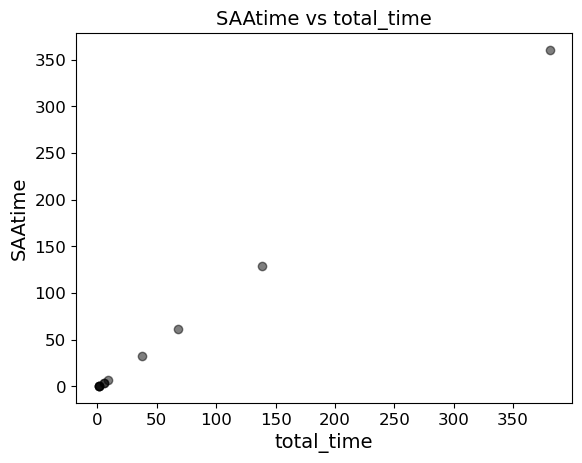

In [91]:
import matplotlib.pyplot as plt
plt.scatter(df_Strat4_1000['total_time'], df_Strat4_1000['SAAtime'], color='black', marker='o',alpha=0.5)
plt.title('SAAtime vs total_time', fontsize=14)
plt.xlabel('total_time', fontsize=14)
plt.ylabel('SAAtime', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.show()
plt.savefig("mainStrat4_total_time_vs_SAAtime.png")

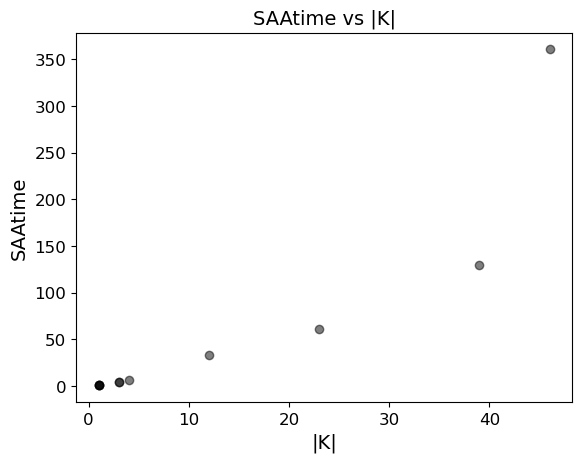

In [93]:
import matplotlib.pyplot as plt
plt.scatter(df_Strat4_1000['K'], df_Strat4_1000['SAAtime'], color='black', marker='o',alpha=0.5)
plt.title('SAAtime vs |K|', fontsize=14)
plt.xlabel('|K|', fontsize=14)
plt.ylabel('SAAtime', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.show()
plt.savefig("mainStrat4_SAAtime_vs_K.png")

In [8]:
df_Strat4_1000

,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.402595,10,330.000000,[ 0 1 2 3 4 5 6 39 75 172],8
1,-1,0.391035,10,330.000000,[ 0 1 2 3 4 5 6 39 75 172],8
2,-1,122.916845,10,371.078125,[ 0 1 2 3 127 134 146 155 161 163],9
3,-1,124.183239,10,371.078125,[ 0 1 2 3 127 134 146 155 161 163],9
4,10,528.015625,[ 2 3 76 78 114 129 131 151 173 185],168.000000,644.110943,70
5,-1,1.318296,10,688.000000,[ 0 1 2 25 38 52 67 70 98 153],10
6,-1,1.199593,10,688.000000,[ 0 1 2 25 38 52 67 70 98 153],10
7,10,112.000000,[ 0 1 2 3 4 5 6 7 8 17],1.000000,0.619513,13
8,10,366.191406,[ 1 3 59 65 83 91 149 162 176 193],24.000000,62.83506,17
9,10,505.000000,[ 0 1 2 3 4 5 6 7 98 116],1.000000,0.67534,28


In [128]:
df_Strat4_5000

,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.387277,10,585.000000,[ 0 1 2 3 4 5 6 7 44 225],8
1,-1,75.194311,10,497.000000,[ 0 2 4 57 165 170 253 272 289 299],2
2,-1,1219.019841,10,509.402508,[ 0 1 40 59 90 205 243 254 277 320],1
3,-1,1206.936786,10,486.491119,[ 0 1 5 17 106 174 234 249 292 299],10
4,-1,233.581529,10,264.234375,[ 0 1 2 3 4 5 118 236 250 292],6
5,-1,0.373258,10,168.000000,[ 0 1 2 3 4 5 6 200 234 260],7


In [131]:
print(len(df_Strat4_5000))
(df_Strat4_5000.total_time.sum()+(10-len(df_Strat4_5000))*3600)/10

6


1713.5493001937866

In [133]:
merged_df = df_Strat4_1000.merge(df_Strat4_5000, on=['Ins'], how='outer')
merged_df = merged_df.merge(df_Strat4_10000, on=['Ins'], how='outer')

In [123]:
merged_df.iloc[:,[4, 10, 15]]

,x_sol_x,x_sol_y,x_sol
0,[ 1 4 77 128 244 270 283 352 427 472],[ 1 4 77 128 244 270 283 352 427 472],NaN
1,[ 2 117 119 137 144 145 148 201 232 495],[ 2 117 119 137 144 145 148 201 232 495],[ 2 117 119 137 144 145 148 201 232 495]
2,[ 0 1 16 42 50 72 167 190 227 299],[ 0 1 16 42 50 72 167 190 227 299],[ 0 1 16 42 50 72 167 190 227 299]
3,[ 0 1 2 22 26 190 228 267 417 436],[ 0 1 2 22 26 190 228 267 417 436],[ 0 1 2 22 26 190 228 267 417 436]
4,[ 0 1 2 10 45 65 247 314 452 461],[ 0 1 2 10 45 65 247 314 452 461],[ 0 1 2 10 45 65 247 314 452 461]
5,[ 0 1 2 3 4 5 6 7 32 156],[ 0 1 2 3 4 5 6 7 32 156],[ 0 1 2 3 4 5 6 7 32 156]
6,[ 0 6 16 28 159 164 273 311 347 420],NaN,[ 0 6 16 28 159 164 273 311 347 420]
